## Setup

In [13]:
import importlib, subprocess, sys
for pkg in ['torch', 'torchvision', 'matplotlib']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [14]:
import os, json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results',     exist_ok=True)
os.makedirs('figures',     exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Model: Logistic Regression (784 → 10)

In [15]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

## Data Loader

In [16]:
BATCH_SIZE = 256

transform = transforms.ToTensor()

train_ds = datasets.MNIST('data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1000,       shuffle=False)

print(f'Train: {len(train_ds):,} samples \nTest: {len(test_ds):,} samples')

Train: 60,000 samples 
Test: 10,000 samples


## Train Clean Baseline

In [17]:
def evaluate_clean(model, loader):
    """
    Return (loss, accuracy) on a DataLoader
    """
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return total_loss / total, correct / total

In [18]:
EPOCHS = 20
LR = 0.01

baseline_model = LogisticRegression().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(baseline_model.parameters(), lr=LR)

print(f'Training logistic regression for {EPOCHS} epochs')
for epoch in range(1, EPOCHS + 1):
    baseline_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        criterion(baseline_model(x), y).backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        _, tr_acc = evaluate_clean(baseline_model, train_loader)
        _, te_acc = evaluate_clean(baseline_model, test_loader)
        print(f'  Epoch {epoch:2d}: train={tr_acc:.4f}  test={te_acc:.4f}')

_, clean_acc = evaluate_clean(baseline_model, test_loader)
print(f'\nFinal clean test accuracy: {clean_acc:.4f}')

torch.save(baseline_model.state_dict(), 'checkpoints/logreg_baseline.pt')
with open('results/baseline_clean_accuracy.json', 'w') as f:
    json.dump({'clean_accuracy': clean_acc}, f, indent=2)
print('Saved model and results.')

Training logistic regression for 20 epochs
  Epoch  1: train=0.8047  test=0.8162
  Epoch  5: train=0.8656  test=0.8760
  Epoch 10: train=0.8805  test=0.8873
  Epoch 15: train=0.8887  test=0.8952
  Epoch 20: train=0.8935  test=0.9000

Final clean test accuracy: 0.9000
Saved model and results.


## FGSM Attack


In [19]:
def fgsm_attack(model, x, y, epsilon):
    """
    Return FGSM-perturbed inputs (in normalized pixel space)
    """
    criterion = nn.CrossEntropyLoss()
    x_adv = x.clone().detach().requires_grad_(True)
    loss  = criterion(model(x_adv), y)
    loss.backward()
    x_adv = (x_adv + epsilon * x_adv.grad.sign()).detach()
    return x_adv


def evaluate_adversarial(model, loader, epsilon):
    """
    Accuracy under FGSM with given epsilon
    """
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if epsilon > 0:
            x = fgsm_attack(model, x, y, epsilon)
        with torch.no_grad():
            correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

## 5. Epsilon Sweep — Baseline Model

In [20]:
EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

print('Running FGSM epsilon sweep on baseline')
baseline_adv_accs = []
for eps in EPSILONS:
    acc = evaluate_adversarial(baseline_model, test_loader, eps)
    baseline_adv_accs.append(acc)
    print(f'\tepsilon={eps:.2f}  accuracy={acc:.4f}')

with open('results/logreg_fgsm_results.json', 'w') as f:
    json.dump({'epsilons': EPSILONS, 'adversarial_accuracies': baseline_adv_accs}, f, indent=2)
print('Saved results')

Running FGSM epsilon sweep on baseline
	epsilon=0.00  accuracy=0.9000
	epsilon=0.05  accuracy=0.6179
	epsilon=0.10  accuracy=0.1970
	epsilon=0.15  accuracy=0.0239
	epsilon=0.20  accuracy=0.0016
	epsilon=0.25  accuracy=0.0001
	epsilon=0.30  accuracy=0.0000
	epsilon=0.35  accuracy=0.0000
	epsilon=0.40  accuracy=0.0000
	epsilon=0.45  accuracy=0.0000
	epsilon=0.50  accuracy=0.0000
Saved results


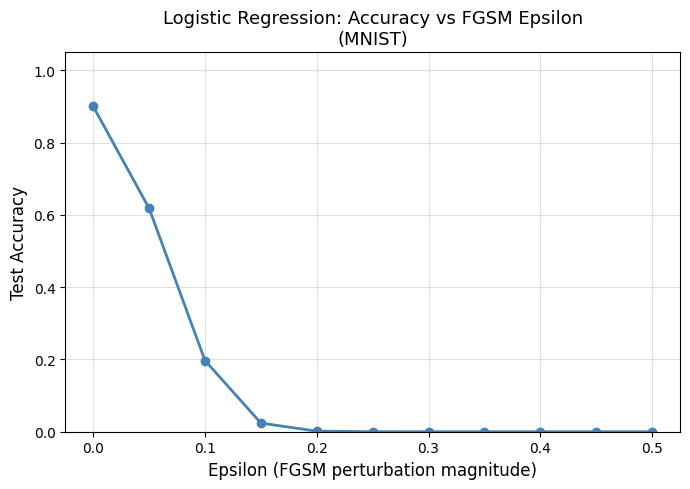

Saved figures/logreg_fgsm_accuracy_vs_epsilon.png


In [21]:
plt.figure(figsize=(7, 5))
plt.plot(EPSILONS, baseline_adv_accs, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epsilon (FGSM perturbation magnitude)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Logistic Regression: Accuracy vs FGSM Epsilon\n(MNIST)', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/logreg_fgsm_accuracy_vs_epsilon.png', dpi=150)
plt.show()
print('Saved figures/logreg_fgsm_accuracy_vs_epsilon.png')

## Linearity Hypothesis

In [22]:
print(f'Clean accuracy (epsilon=0):  {baseline_adv_accs[0]:.4f}')
for eps, acc in zip(EPSILONS[1:], baseline_adv_accs[1:]):
    drop = baseline_adv_accs[0] - acc
    print(f'\tepsilon={eps:.2f}  accuracy={acc:.4f}  (drop={drop:.4f})')

Clean accuracy (epsilon=0):  0.9000
	epsilon=0.05  accuracy=0.6179  (drop=0.2821)
	epsilon=0.10  accuracy=0.1970  (drop=0.7030)
	epsilon=0.15  accuracy=0.0239  (drop=0.8761)
	epsilon=0.20  accuracy=0.0016  (drop=0.8984)
	epsilon=0.25  accuracy=0.0001  (drop=0.8999)
	epsilon=0.30  accuracy=0.0000  (drop=0.9000)
	epsilon=0.35  accuracy=0.0000  (drop=0.9000)
	epsilon=0.40  accuracy=0.0000  (drop=0.9000)
	epsilon=0.45  accuracy=0.0000  (drop=0.9000)
	epsilon=0.50  accuracy=0.0000  (drop=0.9000)


## Adversarial Training

In [23]:
ADV_EPSILON = 0.25

adv_model  = LogisticRegression().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(adv_model.parameters(), lr=LR)

print(f'Adversarial training (epsilon={ADV_EPSILON}) for {EPOCHS} epochs')
for epoch in range(1, EPOCHS + 1):
    adv_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        x_adv    = fgsm_attack(adv_model, x, y, ADV_EPSILON)
        x_mixed  = torch.cat([x, x_adv], dim=0)
        y_mixed  = torch.cat([y, y],     dim=0)

        adv_model.train()
        optimizer.zero_grad()
        criterion(adv_model(x_mixed), y_mixed).backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        c_acc = evaluate_adversarial(adv_model, test_loader, 0.0)
        a_acc = evaluate_adversarial(adv_model, test_loader, ADV_EPSILON)
        print(f'\tEpoch {epoch:2d}: clean={c_acc:.4f}, adv(ε={ADV_EPSILON})={a_acc:.4f}')

torch.save(adv_model.state_dict(), 'checkpoints/logreg_adv_trained.pt')
print('Saved model')

Adversarial training (epsilon=0.25) for 20 epochs
	Epoch  1: clean=0.7855, adv(ε=0.25)=0.1049
	Epoch  5: clean=0.8124, adv(ε=0.25)=0.1266
	Epoch 10: clean=0.8133, adv(ε=0.25)=0.1321
	Epoch 15: clean=0.8137, adv(ε=0.25)=0.1391
	Epoch 20: clean=0.8133, adv(ε=0.25)=0.1426
Saved model


## Baseline vs Adversarially Trained

In [24]:
print('Epsilon sweep: baseline vs adversarially trained')
adv_trained_accs = []
for eps in EPSILONS:
    b_acc = evaluate_adversarial(baseline_model, test_loader, eps)
    a_acc = evaluate_adversarial(adv_model, test_loader, eps)
    adv_trained_accs.append(a_acc)
    print(f'  epsilon={eps:.2f}  baseline={b_acc:.4f}  adv_trained={a_acc:.4f}')

with open('results/logreg_adv_training_results.json', 'w') as f:
    json.dump({
        'epsilons':              EPSILONS,
        'baseline_accuracies':   baseline_adv_accs,
        'adv_trained_accuracies': adv_trained_accs,
        'adv_train_epsilon':     ADV_EPSILON,
    }, f, indent=2)
print('Saved results/logreg_adv_training_results.json')

Epsilon sweep: baseline vs adversarially trained
  epsilon=0.00  baseline=0.9000  adv_trained=0.8133
  epsilon=0.05  baseline=0.6179  adv_trained=0.7060
  epsilon=0.10  baseline=0.1970  adv_trained=0.5720
  epsilon=0.15  baseline=0.0239  adv_trained=0.4189
  epsilon=0.20  baseline=0.0016  adv_trained=0.2706
  epsilon=0.25  baseline=0.0001  adv_trained=0.1426
  epsilon=0.30  baseline=0.0000  adv_trained=0.0465
  epsilon=0.35  baseline=0.0000  adv_trained=0.0074
  epsilon=0.40  baseline=0.0000  adv_trained=0.0006
  epsilon=0.45  baseline=0.0000  adv_trained=0.0000
  epsilon=0.50  baseline=0.0000  adv_trained=0.0000
Saved results/logreg_adv_training_results.json


In [25]:
print(f'\n{"Epsilon":>8}  {"Baseline":>10}  {"Adv-Trained":>12}')
print('-' * 36)
for eps, b, a in zip(EPSILONS, baseline_adv_accs, adv_trained_accs):
    print(f'{eps:>8.2f}  {b:>10.4f}  {a:>12.4f}')


 Epsilon    Baseline   Adv-Trained
------------------------------------
    0.00      0.9000        0.8133
    0.05      0.6179        0.7060
    0.10      0.1970        0.5720
    0.15      0.0239        0.4189
    0.20      0.0016        0.2706
    0.25      0.0001        0.1426
    0.30      0.0000        0.0465
    0.35      0.0000        0.0074
    0.40      0.0000        0.0006
    0.45      0.0000        0.0000
    0.50      0.0000        0.0000


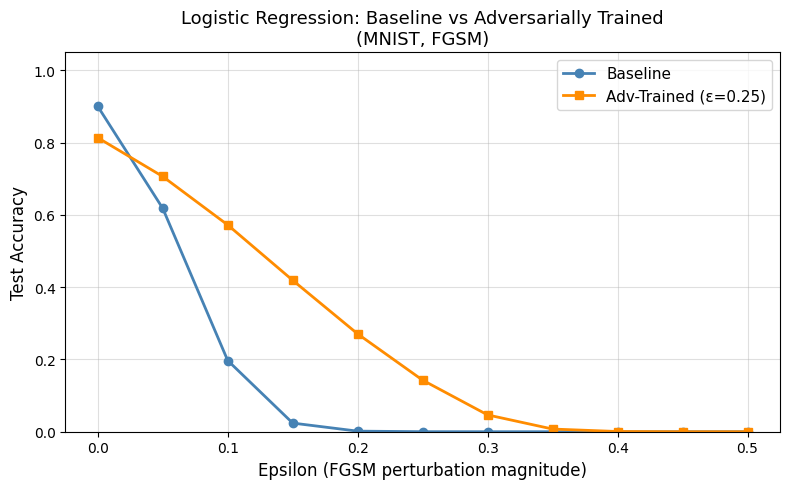

Saved figures/logreg_baseline_vs_adv_trained.png


In [26]:
plt.figure(figsize=(8, 5))
plt.plot(EPSILONS, baseline_adv_accs,  marker='o', linewidth=2, color='steelblue',  label='Baseline')
plt.plot(EPSILONS, adv_trained_accs,   marker='s', linewidth=2, color='darkorange', label=f'Adv-Trained (ε={ADV_EPSILON})')
plt.xlabel('Epsilon (FGSM perturbation magnitude)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Logistic Regression: Baseline vs Adversarially Trained\n(MNIST, FGSM)', fontsize=13)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/logreg_baseline_vs_adv_trained.png', dpi=150)
plt.show()
print('Saved figures/logreg_baseline_vs_adv_trained.png')

## Results

In [27]:
print('=' * 55)
print('RESULTS SUMMARY — Logistic Regression on MNIST')
print('=' * 55)
print(f'Clean baseline accuracy:          {baseline_adv_accs[0]:.4f}')
print(f'Adv-trained clean accuracy:       {adv_trained_accs[0]:.4f}')
print(f'Baseline accuracy at ε=0.1:       {baseline_adv_accs[2]:.4f}')
print(f'Adv-trained accuracy at ε=0.1:    {adv_trained_accs[2]:.4f}')
print(f'Baseline accuracy at ε=0.25:       {baseline_adv_accs[6]:.4f}')
print(f'Adv-trained accuracy at ε=0.25:    {adv_trained_accs[6]:.4f}')
print()
print('Saved files:')
for f in ['results/baseline_clean_accuracy.json',
          'results/logreg_fgsm_results.json',
          'results/logreg_adv_training_results.json',
          'figures/logreg_fgsm_accuracy_vs_epsilon.png',
          'figures/logreg_baseline_vs_adv_trained.png',
          'checkpoints/logreg_baseline.pt',
          'checkpoints/logreg_adv_trained.pt']:
    print(f'  {f}')

RESULTS SUMMARY — Logistic Regression on MNIST
Clean baseline accuracy:          0.9000
Adv-trained clean accuracy:       0.8133
Baseline accuracy at ε=0.1:       0.1970
Adv-trained accuracy at ε=0.1:    0.5720
Baseline accuracy at ε=0.25:       0.0000
Adv-trained accuracy at ε=0.25:    0.0465

Saved files:
  results/baseline_clean_accuracy.json
  results/logreg_fgsm_results.json
  results/logreg_adv_training_results.json
  figures/logreg_fgsm_accuracy_vs_epsilon.png
  figures/logreg_baseline_vs_adv_trained.png
  checkpoints/logreg_baseline.pt
  checkpoints/logreg_adv_trained.pt
